# CME Futures: Features That Are Themselves Model Output

Every feature so far has been a formula applied to past prices. This notebook builds
features of a second kind: it estimates a statistical model from past prices and then
emits what that model says about each session as the feature. All three models start
from the same quantity, the **carry** of a futures product - the price difference
between the contract expiring soonest and the one expiring after it, which is what a
trader holding a position earns or pays each time the position is rolled from one to
the next.

1. **ARIMA** forecasts next session's carry from the recent path of carry, one forecast
   per product per session.
2. **A rolling Fourier transform** measures which cycle lengths the carry of a product
   has been oscillating at over the past year.
3. **A two-state hidden Markov model** reads one number per session - carry averaged
   across the whole book - and infers which of two market states the book is in.

It reads the raw CME settlement prices and the forward-return labels written by
[`02_labels`](02_labels.ipynb), and it writes one artifact,
`features/model_based.parquet`.

**What you will be able to do after reading this**

- Say why estimating a model on all your data and then using its output as a feature
  gives you a number no one could have computed at the time, and recognise the shape of
  that mistake in your own code.
- Split a price history into training and evaluation periods, estimate a model on the
  training part alone, and run it forward over the evaluation part without ever letting
  it re-read the evaluation part.
- Run a hidden Markov model so that its answer for a given day uses that day and every
  earlier day but no later day, and check by experiment that this is what it did.
- Write the resulting features to a file that records which prices they came from, so a
  model trained on them later can state which version of the features it read.

**Book Reference**: Chapter 9, Sections 9.3-9.5

**Prerequisites**: [`02_labels`](02_labels.ipynb). It writes the forward-return file
this notebook reads, and the dates in that file are what the training and evaluation
periods below are cut from. [`03_financial_features`](03_financial_features.ipynb) runs
as a parallel branch on the same raw prices; the two feature sets are read together by
the model notebooks in Chapter 11.

In [1]:
"""CME Futures: Temporal Feature Engineering."""

import multiprocessing
import re
import time
import warnings
from datetime import date

# Pin the start method to fork before any pool-using import: Python 3.14 defaults to
# forkserver, which re-executes this script in every StatsForecast worker.
if multiprocessing.get_start_method(allow_none=True) is None:
    multiprocessing.set_start_method("fork")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from hmmlearn.hmm import GaussianHMM
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from threadpoolctl import threadpool_limits

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.temporal import (
    filtered_state_probs,
    fit_hmm_kmeans_init,
    sort_states_by_mean,
)
from data import load_cme_futures
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

warnings.filterwarnings("ignore")

## Configuration

Seven settings, and each one decides something a reader would otherwise have to guess
at. `MAX_PRODUCTS` and `MAX_FOLDS` exist so a smoke test can run a fraction of the
work; both are zero here, which means the full universe and every period.

In [2]:
CASE_STUDY_ID = "cme_futures"
SEED = 42
# Number of products to model. Zero means all thirty; a positive value takes that many
# from the front of the list and is only for a fast check that the code runs.
MAX_PRODUCTS = 0
# Number of walk-forward periods to fit. Zero means all of them. The three models are
# re-estimated once per period, so this is the setting that scales the running time.
MAX_FOLDS = 0
# How many past sessions each Fourier transform reads: 252, one trading year. A cycle
# can only be measured if the window is long enough to contain it more than once, so a
# year-long window is the shortest one from which a half-year cycle is legible.
FFT_WINDOW = 252
# The two cycle lengths whose strength is reported as a feature, in trading sessions:
# 63 is a quarter and 126 is half a year. Agricultural and energy contracts have
# seasonal supply and demand at both.
FFT_TARGET_PERIODS = [63, 126]
# The share of false positives tolerated among the features section F declares
# significant, after correcting for how many were tested at once.
FDR_ALPHA = 0.05
# How much of a product's history inside a period is spent before the first ARIMA
# forecast: 252, a trading year, so the first order is chosen from a full year of the
# series. It also sets how many forecasts the walk makes, one per session after it.
ARIMA_BURNIN = 252
# How often the ARIMA order and weights are re-chosen as the walk proceeds: 21, monthly.
# The stepwise order search is the expensive step, so this is what bounds the walk's cost
# without changing how many products or periods it covers.
ARIMA_REFIT_FREQ = 21

Three more settings come from `config/setup.yaml`, the file that also configures
[`03_financial_features`](03_financial_features.ipynb). The universe is the thirty
products and the sectors they belong to. The two windows are the ones that stage uses
to smooth carry and to express it as a z-score - the number of standard deviations
carry sits from its own recent average - so that the series built in section C is the
same series that stage writes under the name `carry_zscore_63d`, in a different shape.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"
STRATEGY_ID = CASE_STUDY_ID
set_global_seeds(SEED)

SETUP = load_setup_config(CASE_STUDY_ID)
PRODUCT_GROUPS = SETUP["universe"]["product_groups"]
ALL_PRODUCTS = [p for products in PRODUCT_GROUPS.values() for p in products]
assert len(ALL_PRODUCTS) == SETUP["universe"]["n_products"], (
    f"setup.yaml declares {SETUP['universe']['n_products']} products, "
    f"product_groups lists {len(ALL_PRODUCTS)}"
)

CARRY_SMOOTHING = int(SETUP["features"]["windows"]["carry_smoothing"])
CARRY_ZSCORE_WINDOW = int(SETUP["features"]["windows"]["carry_zscore"][0])

# Two sessions carry one clearing venue's settlement file and not the other's; `setup.yaml`
# says which and why. They are dropped here so no series is differenced across a date on
# which half the universe has no settlement price.
EXCLUDED_SESSIONS = [
    date.fromisoformat(str(d)) for d in SETUP["universe"].get("excluded_sessions", [])
]

if MAX_PRODUCTS > 0:
    ARIMA_PRODUCTS = ALL_PRODUCTS[:MAX_PRODUCTS]
else:
    ARIMA_PRODUCTS = ALL_PRODUCTS

print(f"Carry is smoothed over {CARRY_SMOOTHING} sessions before anything reads it.")
print(
    f"Its z-score is taken against the previous {CARRY_ZSCORE_WINDOW} sessions of that "
    f"smoothed series."
)
print(f"Modelling {len(ARIMA_PRODUCTS)} of the {len(ALL_PRODUCTS)} products in the universe.")

Carry is smoothed over 21 sessions before anything reads it.
Its z-score is taken against the previous 63 sessions of that smoothed series.
Modelling 30 of the 30 products in the universe.


## The data these models read

One row per product, expiry and session, carrying that contract's settlement price.
**Product** is a futures contract's underlying - corn, gold, the S&P 500 index - and
each product trades in several contracts at once that differ only in when they expire.
Those are indexed by `position`: position 0 is the contract expiring soonest, the
**front month**; position 1 is the one after it; position 2 the one after that.

In [4]:
df = load_cme_futures(products=sorted(ALL_PRODUCTS)).rename(
    {"session_date": "timestamp", "tenor": "position"}
)
df = df.filter(~pl.col("timestamp").is_in(EXCLUDED_SESSIONS))

if MAX_PRODUCTS > 0:
    df = df.filter(pl.col("product").is_in(ARIMA_PRODUCTS))

print(f"Loaded {len(df):,} rows, {df['product'].n_unique()} products")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loaded 312,778 rows, 30 products
Date range: 2011-01-03 to 2025-12-31


The thirty products are not thirty interchangeable series. They are seven groups of
things that move for their own reasons, and the models below fit one product at a time,
so a product's group is what the reader should carry forward about it.

Each row is one sector: the products in it, the session its earliest product first
quoted, the session by which all of them were quoting, and how many front-month
product-sessions it contributes. Two things to read off it.

The panel starts together. Every sector's two date columns hold the same session, with
one exception, and that exception is why the equity-index row contributes fewer sessions
than any other four-product sector. Comparing the two date columns is how to find it.

The rest of the spread in the session counts is holiday calendars. These sectors do not
close on the same days, so per product the agricultural and livestock contracts quote
about a hundred fewer sessions across the panel than the financial ones. That is a small
effect for a model fitted one product at a time, and a large one for section C.3, which
has to average carry across all of them on every session and therefore has to decide
what to do about the ones that did not settle.

In [5]:
_front = df.filter(pl.col("position") == 0)
_sector_of = {p: sector for sector, products in PRODUCT_GROUPS.items() for p in products}
universe_table = (
    _front.with_columns(
        pl.col("product").replace_strict(_sector_of, default="unclassified").alias("sector")
    )
    .group_by(["sector", "product"])
    .agg(pl.col("timestamp").min().alias("product_start"), pl.len().alias("sessions"))
    .group_by("sector")
    .agg(
        pl.col("product").sort().str.join(" ").alias("products"),
        pl.col("product").n_unique().alias("n_products"),
        pl.col("product_start").min().alias("first_product_quoting"),
        pl.col("product_start").max().alias("all_products_quoting"),
        pl.col("sessions").sum().alias("front_month_sessions"),
    )
    .sort("front_month_sessions", descending=True)
)
universe_table

sector,products,n_products,first_product_quoting,all_products_quoting,front_month_sessions
str,str,u32,date,date,u32
"""currencies""","""6A 6B 6C 6E 6J 6S""",6,2011-01-03,2011-01-03,23148
"""agriculture""","""ZC ZL ZM ZS ZW""",5,2011-01-03,2011-01-03,18864
"""energy""","""CL HO NG RB""",4,2011-01-03,2011-01-03,15472
"""metals""","""GC HG PL SI""",4,2011-01-03,2011-01-03,15469
"""treasuries""","""ZB ZF ZN ZT""",4,2011-01-03,2011-01-03,15445
"""equity_index""","""ES NQ RTY YM""",4,2011-01-03,2017-07-10,13787
"""livestock""","""GF HE LE""",3,2011-01-03,2011-01-03,11291


## A. Why a feature built from a fitted model is a different hazard

The features in [`03_financial_features`](03_financial_features.ipynb) are formulas. A
63-session average of carry on 3 March reads carry on the 63 sessions up to 3 March and
nothing else, so whether it could have been computed at the time is settled by looking
at the formula.

The features in this notebook are not formulas. Each one is the output of a model whose
**parameters were estimated from data**, and those parameters are part of what the
feature knows. Suppose the hidden Markov model in section C is estimated once on the
whole price history and then asked which state the market was in on 3 March 2016. Its
answer depends on the two state means and the transition probabilities it settled on,
and those were computed from every session in the file - including 2023. Nothing in the
formula for 3 March mentions 2023. The dependence runs through the parameters instead,
and it is invisible at the point where the number is used.

That failure is worth naming precisely because it does not announce itself. The
notebook runs without error, the feature looks reasonable, and it correlates with future
returns better than it should - because it was partly built from them. A model trained
on such a feature reports a performance the same strategy could never have earned, and
the gap only appears when someone tries to trade it.

The rule that removes it is one sentence: **no parameter behind the value for a session
may have seen that session or any later one.** It has two halves, and both are enforced
below.

**Bound where the parameters come from.** There are two honest ways to do that, and this
notebook uses both, because they suit different models. One is to estimate once per
period on that period's training sessions and then hold the parameters fixed while the
model is applied forward - what the hidden Markov model in C.3 does, and what section
C.3 asserts by comparing the last session behind every estimate against its own training
end. The other is to re-estimate as the walk proceeds - what ARIMA in C.1 does, refitting
every `ARIMA_REFIT_FREQ` sessions on everything up to that point, so its weights go on
being refreshed across the evaluation window and each set is fitted only on sessions
earlier than the ones it then forecasts. Both are causal. What neither may do is fit on
the session it is about to speak for.

**Run the fitted model forward, never backward.** Even a model estimated on training
data can look ahead when it is *applied*. A hidden Markov model can be asked two
different questions about 3 March: what is the most likely state given everything up to
3 March, or given the whole series. The second question is the one the standard library
call answers by default, and its answer for 3 March changes when data from April
arrives. Only the first is a quantity that existed on 3 March. Section C runs the first
and demonstrates the difference by deleting the later observations and checking the
number does not move.

## B. The periods, and what is estimated where

The walk-forward boundaries are resolved here, **before any model is fitted**, because
every fit below is bounded by them.

They are derived from the forward-return file rather than from the price file. The two
do not span the same dates: a forward return needs a window after it to resolve, so the
label file stops earlier than the prices. The model notebooks downstream cut their
periods from the label file, so cutting from the same frame here is what makes a period
number in this artifact mean the same thing on both sides of the join.

Three things are resolved here and used everywhere below.

**Which forward return the case study is built around.** It is read from the
configuration rather than typed, because the same choice has to pick three things at
once: the file [`02_labels`](02_labels.ipynb) wrote, the gap left between each training
and evaluation window, and the correlation lag in section F.

**The gap between training and evaluation.** A decision made on the last training
session is only settled `LABEL_HORIZON_SESSIONS` sessions later. If evaluation began the
next session, the model would be scored on days whose outcome overlaps days it was
trained on. So the two windows are held that far apart. The practice is called
**purging**, and the gap is what `LABEL_BUFFER` sizes.

**Where the holdout begins.** The last stretch of history is held back and not read by
anything in the research process, so that there is one period left at the end on which
the finished strategy can be run as if for the first time. Its first session is
`HOLDOUT_START`.

Section F needs a stricter boundary than that. It scores features against a forward
return, and a decision on date `t` is settled `LABEL_HORIZON_SESSIONS` sessions after
`t`. For that outcome to be observable outside the holdout, `t` itself has to fall that
many sessions earlier than the holdout does - so the last date section F may score is
`LAST_SCORABLE_DECISION_DATE`, counted on the sessions the exchange actually traded.

In [6]:
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
LABEL_HORIZON_SESSIONS = int(re.match(r"^(\d+)", LABEL_BUFFER).group(1))

label_frame = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
splits = generate_cv_splits(
    label_frame.select("timestamp").unique().sort("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)
if MAX_FOLDS > 0:
    splits = splits[:MAX_FOLDS]


def _as_date(value) -> date:
    return pd.Timestamp(value).date()


HOLDOUT_START = _as_date(load_evaluation_config(CASE_STUDY_ID)["holdout_start"])
_sessions = df.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
_pre_holdout = [d for d in _sessions if d < HOLDOUT_START]
LAST_SCORABLE_DECISION_DATE = _pre_holdout[-(LABEL_HORIZON_SESSIONS + 1)]

print(
    f"Predicting {PRIMARY_LABEL}, so training and evaluation are held "
    f"{LABEL_HORIZON_SESSIONS} sessions apart."
)
print(f"{len(splits)} walk-forward periods, most recent first:")
for s in splits:
    print(
        f"  Period {s['fold']}: train {s['train_start']} → {s['train_end']}, "
        f"evaluate {s['val_start']} → {s['val_end']}"
    )
print(
    f"The holdout opens {HOLDOUT_START}. Section F scores no decision after "
    f"{LAST_SCORABLE_DECISION_DATE}, so every outcome it reads is settled before that."
)

Predicting fwd_ret_5d, so training and evaluation are held 5 sessions apart.
5 walk-forward periods, most recent first:
  Period 0: train 2015-01-05 00:00:00 → 2022-12-22 00:00:00, evaluate 2023-01-03 00:00:00 → 2023-12-21 00:00:00
  Period 1: train 2014-01-02 00:00:00 → 2021-12-23 00:00:00, evaluate 2022-01-03 00:00:00 → 2022-12-30 00:00:00
  Period 2: train 2012-12-31 00:00:00 → 2020-12-24 00:00:00, evaluate 2021-01-05 00:00:00 → 2021-12-31 00:00:00
  Period 3: train 2012-01-03 00:00:00 → 2019-12-24 00:00:00, evaluate 2020-01-03 00:00:00 → 2021-01-04 00:00:00
  Period 4: train 2011-01-04 00:00:00 → 2018-12-24 00:00:00, evaluate 2019-01-03 00:00:00 → 2020-01-02 00:00:00
The holdout opens 2024-01-01. Section F scores no decision after 2023-12-21, so every outcome it reads is settled before that.


The figure draws what the saved file will contain: for each period, its training
window, the evaluation window that follows, and the holdout.

Read it with section A's rule in hand. The training window is where the hidden Markov
model's parameters come from, all of them, which is why C.3 can check its estimates
against the right-hand edge of that bar. ARIMA's weights are not confined to it - they
are refreshed every `ARIMA_REFIT_FREQ` sessions across the evaluation window too - so
what bounds ARIMA is not this picture but the direction it walks, which C.1 sets out. What the figure does show for
both is the gap between the two bars, sized to the label horizon so that no training
session's outcome reaches into the window the model is scored on, and that no bar
crosses into the shaded region at all.

Every bar stops short of the holdout, because this notebook writes features for the
walk-forward periods only. A later stage that needs the models fitted through to the
holdout as well builds that period itself, from `append_holdout_fold_if_needed`.

The bars are periods, not the file's row index. Rows are keyed on
`(fold, timestamp, product, position)` across the whole price calendar, so rows dated
inside the holdout do exist in the file. What keeps them honest is which columns carry
a value there, and section E prints that count column by column. A model that reads no
forward return is bounded by where its *parameters* came from, so emitting a value
**for** a holdout date from parameters estimated entirely before it is exactly what the
later stages need.

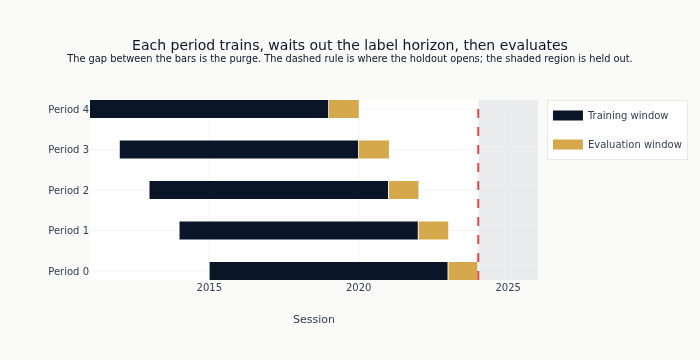

In [7]:
fig = go.Figure()
_span_style = {
    "Training window": COLORS["blue"],
    "Evaluation window": COLORS["amber"],
}
_seen: set[str] = set()
for split in splits:
    row = f"Period {split['fold']}"
    for kind, (start, end) in (
        ("Training window", (split["train_start"], split["train_end"])),
        ("Evaluation window", (split["val_start"], split["val_end"])),
    ):
        fig.add_trace(
            go.Scatter(
                x=[pd.Timestamp(start).isoformat(), pd.Timestamp(end).isoformat()],
                y=[row, row],
                mode="lines",
                line={"width": 18, "color": _span_style[kind]},
                name=kind,
                legendgroup=kind,
                showlegend=kind not in _seen,
            )
        )
        _seen.add(kind)

fig.add_vrect(
    x0=pd.Timestamp(HOLDOUT_START).isoformat(),
    x1=pd.Timestamp(df["timestamp"].max()).isoformat(),
    fillcolor=COLORS["neutral"],
    opacity=0.10,
    line_width=0,
    layer="below",
)
fig.add_vline(
    x=pd.Timestamp(HOLDOUT_START).isoformat(), line_dash="dash", line_color=COLORS["negative"]
)
fig.update_layout(
    title=(
        "Each period trains, waits out the label horizon, then evaluates"
        "<br><sup>The gap between the bars is the purge. The dashed rule is where the "
        "holdout opens; the shaded region is held out.</sup>"
    ),
    xaxis_title="Session",
    yaxis_title="",
    height=360,
    margin={"l": 90},
)
show_plotly_with_alt(
    fig,
    "Horizontal timeline with one row per period, periods 0 to 4, running from about 2012 to "
    "2025. Each row shows a long dark training window followed, after a visible gap, by a "
    "shorter amber evaluation window; the gap between them is the purge that waits out the label "
    "horizon. The windows step forward period by period. A dashed vertical rule marks where the "
    "holdout opens and a shaded band covers everything after it; no evaluation window reaches "
    "into that band.",
)

## The input all three models read: carry

Carry is how far the front-month contract settles above the next one along, as a
fraction of the front price, scaled by twelve:

$$c_{p,t} = 12 \times \frac{F^{(0)}_{p,t} - F^{(1)}_{p,t}}{F^{(0)}_{p,t}}$$

where the superscript is the contract position. A trader holding the front month has to
replace it with the next contract before it expires, and that gap is what the
replacement earns or costs. It is positive in **backwardation**, where the nearer
contract is the dearer one, and negative in **contango**, where it is the cheaper one.

**The twelve is a scale factor, not an annual rate.** It would turn a one-month spread
into a yearly one, and the four energy curves in this universe do list a contract every
month. The other twenty-six are on quarterly or irregular cycles, so for them twelve is
the wrong multiple for an annual rate and the number is not one. It is the same constant
for every product on every date, so it changes no ranking and no z-score; what it does
not deliver is a level that means the same thing on a Treasury curve as on a crude one.

Two derived series come out of it. **Smoothed carry** is carry averaged over
`CARRY_SMOOTHING` sessions, which removes the daily settlement noise the models would
otherwise fit. **The carry z-score** expresses that smoothed level as the number of
standard deviations it sits from its own average over the previous
`CARRY_ZSCORE_WINDOW` sessions, so that gold in dollars and corn in cents can be
compared on one scale.

[`03_financial_features`](03_financial_features.ipynb) writes the same z-score under the
name `carry_zscore_63d`, but with one row per contract rather than one per product. The
models here need one series per product, so the same definition is recomputed in that
shape from the raw prices - both windows read from the same configuration - rather than
reshaped out of that file. This is why the file this notebook writes records the raw
prices as its input and no other feature file.

In [8]:
def compute_carry(data: pl.DataFrame) -> pl.DataFrame:
    """Compute carry percentage from front and deferred month prices."""
    # Raw (unadjusted) close: the term-structure spread must read contemporaneous
    # tenor levels, not the ratio-adjusted series whose levels encode roll history.
    front = (
        data.filter(pl.col("position") == 0)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c0_price"})
    )
    second = (
        data.filter(pl.col("position") == 1)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c1_price"})
    )

    carry_df = front.join(second, on=["product", "timestamp"], how="inner")
    carry_df = carry_df.with_columns(
        ((pl.col("c0_price") - pl.col("c1_price")) / pl.col("c0_price") * 12).alias("carry_pct")
    )

    # Smoothed carry and z-score, on the windows setup.yaml declares
    carry_df = carry_df.sort(["product", "timestamp"])
    carry_df = carry_df.with_columns(
        pl.col("carry_pct")
        .rolling_mean(window_size=CARRY_SMOOTHING)
        .over("product")
        .alias("carry_smoothed"),
    )
    carry_df = carry_df.with_columns(
        (
            (
                pl.col("carry_smoothed")
                - pl.col("carry_smoothed").rolling_mean(CARRY_ZSCORE_WINDOW).over("product")
            )
            / pl.col("carry_smoothed")
            .rolling_std(CARRY_ZSCORE_WINDOW)
            .over("product")
            .clip(lower_bound=1e-6)
        )
        .clip(lower_bound=-5.0, upper_bound=5.0)
        .alias("carry_zscore")
    )

    return carry_df.select(
        ["product", "timestamp", "carry_pct", "carry_smoothed", "carry_zscore"]
    ).drop_nulls()


carry = compute_carry(df)
print(f"Carry data: {len(carry):,} product-dates")

Carry data: 108,952 product-dates


---

## C. The three models

Each subsection below states what the model infers, where its parameters are allowed to
come from, and ends with an assertion that runs - not a comment claiming the
window held, but a check that fails the notebook if it did not.

### C.1 ARIMA: what carry does next

Term structure changes gradually, so today's carry z-score carries information about
tomorrow's. ARIMA is the standard model for that kind of series: it writes the next
value as a weighted sum of recent values and of recent forecast errors, and estimates
the weights. Its three orders say how many of each go in - `p` past values, `q` past
errors, and `d` differences taken first if the series drifts rather than reverting.

The orders are not chosen by hand. `AutoARIMA` runs the standard stepwise search,
considering `p` and `q` up to 5, picking `d` by a statistical test for whether the
series reverts at all, and preferring the combination that fits best after a penalty
for the number of weights it uses. Seasonal terms are excluded from that search,
because the seasonality this case study cares about is measured directly in C.2.

**Why every value it emits is a forecast and not a fit.** Within each period, one call
walks the window a session at a time: at each step the model sees the history up to
that session and predicts the next one. What is emitted for a session is therefore the
prediction made before the session happened, over training dates and evaluation dates
alike, and the weights behind it are re-estimated every `ARIMA_REFIT_FREQ` steps.
There are no fitted-in-place values anywhere in the output. The walk cannot begin until
there is enough history to estimate from, so the first `ARIMA_BURNIN` sessions of each
product's history inside the period get no value.

The two features are the forecast itself, `arima_carry_forecast`, and what it missed,
`arima_carry_residual` - the realised z-score minus the forecast. A large residual says
carry moved in a way its own recent path did not imply.

Every product with enough history goes into one call per period, as a long frame keyed
by product and date. The library walks those series together, spread across cores. It is
the same walk-forward routine as
[`10_uncertainty_features`](../../09_model_based_features/10_uncertainty_features.ipynb).

Two settings govern the walk, and both are bound in the parameters cell so a reduced
run can lower the cost of this section without narrowing the universe or the periods.
`ARIMA_BURNIN` is how much of a product's history inside a period is spent before the
first forecast: a trading year, so the first order is chosen from a full year of the
series rather than from a few weeks of it. `ARIMA_REFIT_FREQ` is how often the order
and weights are re-chosen as the walk proceeds: monthly, which keeps them current
without repeating the order search on every session of a training window that runs to
several thousand.

In [9]:
_carry_ts_dtype = carry.schema["timestamp"]

The carry frame carries `pl.Date`, so a bound written as a Python date is cast to the
column's own dtype; that is what makes an inclusive upper bound cover the last session.

In [10]:
def _date_lit(value) -> pl.Expr:
    """Cast a Python date or timestamp to the carry frame's timestamp dtype."""
    return pl.lit(pd.Timestamp(value).date()).cast(_carry_ts_dtype)

One period: the products with enough history to model, the walk length they share, and
the forecasts the library returns for every product-date inside the window. The walk
has to be the same length for every series in one call, so the shortest one sets it:
each product walks over its final (shortest length minus burn-in) sessions, and a
product with more history in this period loses the excess off the front. What that
costs is measured two cells below.

In [11]:
def _arima_fold(split: dict, fold_idx: int) -> pl.DataFrame | None:
    """One-step walk-forward ARIMA forecasts for every eligible product in one fold."""
    print(
        f"\nFold {fold_idx}: train {_as_date(split['train_start'])}→"
        f"{_as_date(split['train_end'])}, test {_as_date(split['val_start'])}→"
        f"{_as_date(split['val_end'])}",
        flush=True,
    )
    in_window = (
        carry.filter(pl.col("product").is_in(ARIMA_PRODUCTS))
        .filter(
            (pl.col("timestamp") >= _date_lit(split["train_start"]))
            & (pl.col("timestamp") <= _date_lit(split["val_end"]))
        )
        .drop_nulls(subset=["carry_zscore"])
        .sort(["product", "timestamp"])
    )
    series_lengths = in_window.group_by("product").len().sort("len")
    eligible = series_lengths.filter(pl.col("len") >= ARIMA_BURNIN + 30)["product"].to_list()
    if not eligible:
        print("  no eligible products for fold")
        return None
    in_window = in_window.filter(pl.col("product").is_in(eligible))

    # The shortest eligible series sets the walk length, because it has to be uniform.
    min_len = int(series_lengths.filter(pl.col("product").is_in(eligible))["len"].min())
    n_windows = min_len - ARIMA_BURNIN
    fold_input = pd.DataFrame(
        {
            "unique_id": in_window["product"].to_list(),
            "ds": pd.to_datetime(in_window["timestamp"].to_list()),
            "y": in_window["carry_zscore"].to_numpy(),
        }
    )
    cv = StatsForecast(models=[AutoARIMA(season_length=1)], freq="B", n_jobs=-1).cross_validation(
        df=fold_input, h=1, step_size=1, n_windows=n_windows, refit=ARIMA_REFIT_FREQ
    )
    print(f"  {len(eligible)} products fitted, n_windows={n_windows}", flush=True)
    return _fold_forecasts(in_window, cv, fold_idx)

The library returns one row per forecast and none for the burn-in head, so the
forecasts are joined back onto the period's own rows and the head stays empty. An empty
cell here means no forecast could have been made, which is a different thing from a
forecast of zero, and the models downstream have to be able to tell them apart.

In [12]:
def _fold_forecasts(in_window: pl.DataFrame, cv: pd.DataFrame, fold_idx: int) -> pl.DataFrame:
    """Join one fold's forecasts back onto its rows and name the two features."""
    cv_pl = (
        pl.from_pandas(cv)
        .rename({"unique_id": "product", "ds": "timestamp"})
        .with_columns(pl.col("timestamp").cast(pl.Date))
    )
    return (
        in_window.select(["product", "timestamp"])
        .join(
            cv_pl.select(["product", "timestamp", "AutoARIMA", "y"]),
            on=["product", "timestamp"],
            how="left",
        )
        .with_columns(
            arima_carry_forecast=pl.col("AutoARIMA"),
            arima_carry_residual=pl.col("y") - pl.col("AutoARIMA"),
            fold=pl.lit(fold_idx, dtype=pl.Int64),
        )
        .select(["timestamp", "product", "arima_carry_forecast", "arima_carry_residual", "fold"])
    )

Every period, in order.

In [13]:
arima_t0 = time.time()
arima_results = [
    fold_df
    for fold_df in (_arima_fold(split, split["fold"]) for split in splits)
    if fold_df is not None
]
arima_elapsed = time.time() - arima_t0


Fold 0: train 2015-01-05→2022-12-22, test 2023-01-03→2023-12-21


  30 products fitted, n_windows=1275



Fold 1: train 2014-01-02→2021-12-23, test 2022-01-03→2022-12-30


  30 products fitted, n_windows=1022



Fold 2: train 2012-12-31→2020-12-24, test 2021-01-05→2021-12-31


  30 products fitted, n_windows=765



Fold 3: train 2012-01-03→2019-12-24, test 2020-01-03→2021-01-04


  30 products fitted, n_windows=507



Fold 4: train 2011-01-04→2018-12-24, test 2019-01-03→2020-01-02


  30 products fitted, n_windows=250


In [14]:
if arima_results:
    arima_pl = pl.concat(arima_results)
    if arima_pl["timestamp"].dtype != pl.Date:
        arima_pl = arima_pl.with_columns(pl.col("timestamp").cast(pl.Date))
    print(
        f"\nARIMA total: {len(arima_pl):,} rows across "
        f"{arima_pl['product'].n_unique()} products, "
        f"{arima_pl['fold'].n_unique()} periods in {arima_elapsed:.0f}s"
    )
else:
    arima_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "product": pl.String,
            "arima_carry_forecast": pl.Float64,
            "arima_carry_residual": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No ARIMA results generated")


ARIMA total: 329,865 rows across 30 products, 5 periods in 995s


**Check what the emitted rows are dated.** The next cell asserts that every row a
period contributes falls inside that period's own span and that no period reaches the
holdout.

Be clear about what that does and does not establish. It bounds the dates ARIMA speaks
for; it does not bound where its weights came from, and no assertion over the output
frame could, because the weights are not in the frame. What bounds them is the shape of
the call: every refit reads a prefix that ends before the sessions it goes on to
forecast, so a weight fitted on a session it then predicts cannot arise. That is a
property of `cross_validation` with `h=1`, not something this notebook re-checks - the
hidden Markov model in C.3, whose parameters are fixed per period and therefore *are*
checkable against a date, is where an assertion of that kind belongs and where one runs.

It then measures what the shared walk length costs. The walk is as long as the shortest
series allows, so a product with more history in this period than that one loses the
excess, and the per-period counts printed above shrink as the periods get earlier. The
count below says where the loss lands: against the product-sessions each evaluation
window actually quotes. That is a coverage question and not a look-ahead question, and
it is what separates the ARIMA row in the coverage table in section E - which is taken
over the whole panel, most of which no walk ever reaches - from the coverage the models
downstream see.

In [15]:
if len(arima_pl) > 0:
    for split in splits:
        rows = arima_pl.filter(pl.col("fold") == split["fold"])
        if len(rows) == 0:
            continue
        assert rows["timestamp"].min() >= _as_date(split["train_start"]), (
            f"period {split['fold']}: ARIMA row before its own train_start"
        )
        assert rows["timestamp"].max() <= _as_date(split["val_end"]), (
            f"period {split['fold']}: ARIMA row after its own val_end"
        )
    assert arima_pl["timestamp"].max() < HOLDOUT_START, "ARIMA emitted a holdout-dated row"
    print(
        f"Every ARIMA row falls inside its own period, across "
        f"{arima_pl['fold'].n_unique()} of them; the last date emitted anywhere is "
        f"{arima_pl['timestamp'].max()}, before the holdout opens on {HOLDOUT_START}."
    )
    print("Evaluation product-sessions carrying an ARIMA value, per period:")
    for split in splits:
        _in_val = (pl.col("timestamp") >= _as_date(split["val_start"])) & (
            pl.col("timestamp") <= _as_date(split["val_end"])
        )
        quoted = carry.filter(_in_val).height
        covered = (
            arima_pl.filter((pl.col("fold") == split["fold"]) & _in_val)
            .drop_nulls("arima_carry_forecast")
            .height
        )
        print(
            f"  period {split['fold']}: {covered:>6,} of {quoted:>6,} quoted "
            f"({100 * covered / max(quoted, 1):.1f}%)"
        )

Every ARIMA row falls inside its own period, across 5 of them; the last date emitted anywhere is 2023-12-21, before the holdout opens on 2024-01-01.
Evaluation product-sessions carrying an ARIMA value, per period:
  period 0:  7,430 of  7,430 quoted (100.0%)
  period 1:  7,561 of  7,561 quoted (100.0%)
  period 2:  7,488 of  7,488 quoted (100.0%)
  period 3:  7,481 of  7,481 quoted (100.0%)
  period 4:  7,398 of  7,516 quoted (98.4%)


---

### C.2 A rolling Fourier transform: which cycles carry is running at

Crops are harvested at the same time each year and heating demand peaks each winter, so
the cost of holding a corn or a natural gas position is not the same in every month.
Carry inherits that rhythm. A Fourier transform is the tool for finding it: it rewrites
a stretch of a series as a sum of waves of different lengths and reports how much of the
series' movement each wave accounts for. That amount is conventionally called the
**power** at that wave's length.

Five numbers per product per session come out of the transform of the previous
`FFT_WINDOW` sessions:

- `fft_dominant_period` - the length, in sessions, of the wave with the most power.
  Near 252 it says the product is running on an annual cycle; near 21 it says the
  movement is monthly and probably not seasonal at all.
- `fft_energy_63d` and `fft_energy_126d` - the share of total power sitting at the two
  cycle lengths declared in `FFT_TARGET_PERIODS`, quarterly and half-yearly.
- `fft_spectral_entropy` - how spread the power is across wave lengths. Low entropy
  means one cycle dominates and the series is close to periodic; high entropy means the
  power is scattered and no cycle stands out, which is what noise looks like.
- `fft_spectral_energy` - the total, which is a measure of how much the series moved at
  all over the window and puts the three shares in context.

The transform of one window. The window's own average is subtracted first, because the
transform reports the flat part of a series - the wave of infinite length - as the
largest component of all, and that says only that carry is negative on average, which
is not a cycle. That component is dropped from every summary for the same reason.

In [16]:
def _fft_window_features(segment: np.ndarray, target_periods: list[int]) -> dict[str, float]:
    centered = segment - segment.mean()
    fft_vals = np.fft.rfft(centered)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(len(segment))
    total_power = np.sum(power[1:])

    output = {
        "total_power": float(total_power),
        "dominant_period": float("nan"),
        "spectral_entropy": float("nan"),
    }
    for period in target_periods:
        output[f"energy_{period}d"] = float("nan")

    if len(power) <= 1 or total_power <= 0:
        return output

    dom_idx = np.argmax(power[1:]) + 1
    if freqs[dom_idx] > 0:
        output["dominant_period"] = float(1.0 / freqs[dom_idx])

    p_norm = power[1:] / total_power
    p_norm = p_norm[p_norm > 0]
    output["spectral_entropy"] = float(-np.sum(p_norm * np.log(p_norm)))

    for period in target_periods:
        target_freq = 1.0 / period
        freq_idx = np.argmin(np.abs(freqs - target_freq))
        low_idx = max(1, freq_idx - 1)
        high_idx = min(len(power), freq_idx + 2)
        output[f"energy_{period}d"] = float(np.sum(power[low_idx:high_idx]) / total_power)
    return output

The window slides one session at a time and each result is written at the index the
window ends *before*, so a value at `t` never reads the observation at `t`.

In [17]:
def rolling_fft_features(
    signal: np.ndarray,
    window: int = 252,
    target_periods: list[int] | None = None,
) -> dict[str, np.ndarray]:
    if target_periods is None:
        target_periods = [63, 126]

    n = len(signal)
    spectral_energy = np.full(n, np.nan)
    dominant_period = np.full(n, np.nan)
    spectral_entropy = np.full(n, np.nan)
    freq_energies = {p: np.full(n, np.nan) for p in target_periods}

    for t in range(window, n):
        window_stats = _fft_window_features(signal[t - window : t], target_periods)
        spectral_energy[t] = window_stats["total_power"]
        dominant_period[t] = window_stats["dominant_period"]
        spectral_entropy[t] = window_stats["spectral_entropy"]
        for period in target_periods:
            freq_energies[period][t] = window_stats[f"energy_{period}d"]

    result = {
        "fft_spectral_energy": spectral_energy,
        "fft_dominant_period": dominant_period,
        "fft_spectral_entropy": spectral_entropy,
    }
    for period, energy in freq_energies.items():
        result[f"fft_energy_{period}d"] = energy
    return result

One product at a time, over its whole history. This transform is the exception in
section C: it estimates nothing. ARIMA fits weights and the model in C.3 fits state
means and transition probabilities, so both have to be confined to a training window;
the transform of a window is a fixed calculation on the numbers in it, with no
parameters to carry information out of one period into another. That makes it safe to
run once over the full history, on the same footing as a rolling average, and the
window is backward-looking, so no session's value reads a later one.

In [18]:
fft_results = []

for product in ARIMA_PRODUCTS:
    prod_carry = (
        carry.filter(pl.col("product") == product)
        .sort("timestamp")
        .drop_nulls(subset=["carry_pct"])
    )
    if len(prod_carry) < FFT_WINDOW + 50:
        continue

    signal = prod_carry["carry_pct"].to_numpy()
    dates = prod_carry["timestamp"].to_list()

    fft_out = rolling_fft_features(signal, window=FFT_WINDOW, target_periods=FFT_TARGET_PERIODS)

    prod_df = pl.DataFrame({"timestamp": dates, "product": product, **fft_out})
    fft_results.append(prod_df)
    valid_count = prod_df.drop_nulls(subset=["fft_spectral_energy"]).height
    print(f"  {product}: {valid_count} valid FFT observations")

  ES: 3781 valid FFT observations


  NQ: 3751 valid FFT observations
  YM: 3742 valid FFT observations
  RTY: 2048 valid FFT observations


  ZN: 3637 valid FFT observations


  ZB: 3658 valid FFT observations
  ZF: 3330 valid FFT observations
  ZT: 3238 valid FFT observations


  CL: 3785 valid FFT observations


...

  ZS: 3690 valid FFT observations


  ZW: 3690 valid FFT observations
  ZM: 3690 valid FFT observations


  ZL: 3690 valid FFT observations


  LE: 3681 valid FFT observations
  HE: 3681 valid FFT observations


  GF: 3681 valid FFT observations


The values are then copied once per period. They are identical in every period, since
nothing was estimated, but the period number is part of the key the models downstream
join on, and it has to be present on every feature or that join needs a special case
for this one column family. The row counts either side of the copy are printed below,
so the multiplication is visible rather than implied.

In [19]:
if fft_results:
    fft_base = pl.concat(fft_results)
    fft_pl = pl.concat([fft_base.with_columns(pl.lit(s["fold"]).alias("fold")) for s in splits])
    print(f"\nSpectral features computed on {len(fft_base):,} distinct product-sessions")
    print(
        f"Copied across periods: {len(fft_pl):,} rows, "
        f"{fft_pl['product'].n_unique()} products, {fft_pl['fold'].n_unique()} periods"
    )
else:
    fft_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "product": pl.String,
            "fft_spectral_energy": pl.Float64,
            "fft_dominant_period": pl.Float64,
            "fft_spectral_entropy": pl.Float64,
            "fft_energy_63d": pl.Float64,
            "fft_energy_126d": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No FFT results generated")


Spectral features computed on 108,952 distinct product-sessions
Copied across periods: 544,760 rows, 30 products, 5 periods


**Check the window looks backward.** With no parameters, the only way this transform
could read the future is through the window itself - an off-by-one in the slice would
be enough. Recomputation is what settles it rather than re-reading the code: delete
every observation after date `t`, transform what is left, and the value at `t` has to
come back identical.

In [20]:
if fft_results:
    probe_product = fft_base["product"][0]
    probe_signal = (
        carry.filter(pl.col("product") == probe_product)
        .sort("timestamp")
        .drop_nulls(subset=["carry_pct"])["carry_pct"]
        .to_numpy()
    )
    probe_t = FFT_WINDOW + 100
    full_pass = rolling_fft_features(
        probe_signal, window=FFT_WINDOW, target_periods=FFT_TARGET_PERIODS
    )
    truncated = rolling_fft_features(
        probe_signal[: probe_t + 1], window=FFT_WINDOW, target_periods=FFT_TARGET_PERIODS
    )
    for key in full_pass:
        assert np.isclose(full_pass[key][probe_t], truncated[key][probe_t], equal_nan=True), key
    print(
        f"Recomputation agrees: for {probe_product} at session {probe_t}, deleting the "
        f"{len(probe_signal) - probe_t - 1} observations that come after it leaves every "
        f"one of its spectral values unchanged."
    )

Recomputation agrees: for ES at session 352, deleting the 3428 observations that come after it leaves every one of its spectral values unchanged.


---

### C.3 A hidden Markov model: which of two states the book is in

The first two models look at one product at a time. This one looks at the whole book:
its input is a single number per session, carry averaged across the thirty products.

A **hidden Markov model** assumes the series was generated by a system that is in one
of a small number of states at any moment, that each state produces observations with
its own average and spread, and that the system switches between states with fixed
probabilities. The states are hidden because they are never observed directly - only
the numbers they produce are - and fitting the model means estimating, from the
observations alone, what those averages, spreads and switching probabilities are.

Two states are used here, and they correspond to the two shapes the term structure
takes. In one, the front contract settles above the next one, so rolling a long
position forward earns the difference; that is **backwardation**, and carry is
positive. In the other, the next contract is the dearer one, so the same roll pays the
difference; that is **contango**, and carry is negative.

Two features come out: `hmm_carry_regime_prob`, the probability the book is in the
higher-carry state, and `hmm_regime_duration`, how many consecutive sessions the more
probable state has held.

**Two things have to be got right, and they are different things.** The parameters are
estimated on each period's training sessions alone. And the state probabilities are
obtained by running the model *forward* - the answer for a session uses that session
and every earlier one, and nothing later. The library's own `predict_proba` answers a
different question, conditioning on the entire series, and its answer for a given
session changes when data from months afterwards arrives. That quantity did not exist
at the time and cannot be a feature. Both are checked by assertion below.

Three pieces of machinery are shared with the other case studies that fit a hidden
Markov model, in `case_studies/utils/temporal.py`: the fit that starts EM from a
k-means partition, the ordering rule below, and the forward recursion. The recursion
in particular reaches into a private part of `hmmlearn`, which is a thing to write
once and document once rather than to copy into every notebook that needs it.

**Fitting the same numbers twice.** The estimation runs on one thread. The seed fixes
which random draw is taken, not the order the arithmetic happens in: k-means adds up
its distances in parallel, floating-point addition is not associative, so a
multi-threaded fit lands on starting means that differ in their last bits, and EM
carries that difference into the transition probabilities. Pinned to one thread, two
runs of this notebook produce the same feature values - which is what the content
fingerprint written in section E is a statement about.

**Giving the two states a stable identity.** EM returns them in whatever order it
converged to, so without a rule the same fitted state can come back as state 0 in one
period and state 1 in the next, and a feature named after one of them would mean
different things in different periods. The rule has to be the quantity the feature name
claims: `hmm_carry_regime_prob` is the probability of the *higher-carry* state, so the
states are ordered on their estimated average carry, lower first. Section D draws the
two averages per period, which is where that ordering can be checked.

#### Building the one number per session the model reads

Carry averaged across the universe sounds simple and is not. Which products go into the
average has to be the same from one session to the next, or the number moves when the
set of contributors changes rather than when carry does. The sectors on this exchange
keep different holiday calendars: a session that closes the metals pits leaves the
grains settling as usual, and an average taken over whatever happened to settle jumps
for a reason that has nothing to do with the term structure.

So a product that does not settle keeps the carry of its last settlement for
`HOLD_LAST_SETTLE_SESSIONS` sessions, carried forward only and never backward. A product
absent for longer than that, or not yet trading at all, is left out of that session's
average rather than represented by a stale number.

The hold covers part of the problem and the cell below measures which part: how many
absences there are, how many last the single closed session the holiday explanation
predicts, how long the longest one runs, and what share of the missing product-sessions
a two-session hold fills. What the hold does not reach shows up as a smaller set of
contributors, and the per-session count of them is printed under it.

That measurement is what sets `HOLD_LAST_SETTLE_SESSIONS`, so it is taken over
pre-holdout sessions only. A constant chosen by looking at the holdout is a parameter
estimated on the holdout, whatever the code that consumes it does afterwards. The
observation series the models read stops at the same boundary, for the same reason.

In [21]:
HOLD_LAST_SETTLE_SESSIONS = 2  # sessions a last settlement stands in for

pre_holdout_carry = carry.filter(pl.col("timestamp") < _date_lit(HOLDOUT_START))
_carry_sessions = (
    pre_holdout_carry.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
)
_session_index = {d: i for i, d in enumerate(_carry_sessions)}
_absence_runs = []
for (_product,), _product_rows in pre_holdout_carry.group_by("product"):
    _seen = np.sort(np.array([_session_index[d] for d in _product_rows["timestamp"].to_list()]))
    _gaps = np.diff(_seen) - 1
    _absence_runs.extend(int(g) for g in _gaps[_gaps > 0])
_absence_runs = np.array(_absence_runs)
_missing_cells = int(_absence_runs.sum())
_held_cells = int(np.minimum(_absence_runs, HOLD_LAST_SETTLE_SESSIONS).sum())

print(
    f"A product goes missing mid-history {len(_absence_runs):,} times, over "
    f"{_missing_cells:,} product-sessions of "
    f"{len(_carry_sessions) * pre_holdout_carry['product'].n_unique():,}."
)
print(
    f"  gone for one session: {(_absence_runs == 1).sum():,}   "
    f"two: {(_absence_runs == 2).sum():,}   "
    f"longer: {(_absence_runs > 2).sum():,}   longest: {_absence_runs.max()} sessions"
)
print(
    f"Holding the last settlement for {HOLD_LAST_SETTLE_SESSIONS} sessions covers "
    f"{_held_cells:,} of the {_missing_cells:,} missing product-sessions "
    f"({100 * _held_cells / _missing_cells:.0f}%)."
)

A product goes missing mid-history 1,729 times, over 2,642 product-sessions of 98,190.
  gone for one session: 1,381   two: 176   longer: 172   longest: 20 sessions
Holding the last settlement for 2 sessions covers 2,077 of the 2,642 missing product-sessions (79%).


The average itself: every product on every session, the hold applied forward, and the
mean over whatever is present.

In [22]:
_basket_grid = (
    pre_holdout_carry.select("timestamp")
    .unique()
    .join(pre_holdout_carry.select("product").unique(), how="cross")
)
held_carry = (
    _basket_grid.join(pre_holdout_carry, on=["product", "timestamp"], how="left")
    .sort(["product", "timestamp"])
    .with_columns(pl.col("carry_pct").forward_fill(limit=HOLD_LAST_SETTLE_SESSIONS).over("product"))
)

portfolio_carry = (
    held_carry.group_by("timestamp")
    .agg(
        pl.col("carry_pct").mean().alias("portfolio_carry"),
        pl.col("carry_pct").is_not_null().sum().alias("products_in_basket"),
    )
    .sort("timestamp")
    .drop_nulls()
)

print(f"The model reads one observation on each of {len(portfolio_carry):,} sessions.")
print(
    f"Products behind each of those averages: "
    f"{portfolio_carry['products_in_basket'].min()} at the thinnest, "
    f"{portfolio_carry['products_in_basket'].max()} at the fullest, "
    f"median {portfolio_carry['products_in_basket'].median():.0f} of {len(ALL_PRODUCTS)}."
)

The model reads one observation on each of 3,273 sessions.
Products behind each of those averages: 6 at the thinnest, 30 at the fullest, median 29 of 30.


How many consecutive sessions the current state has held, counted forward from the
first session of the window:

In [23]:
def _regime_duration(test_states: np.ndarray) -> np.ndarray:
    duration = np.zeros(len(test_states))
    duration[0] = 1
    for t in range(1, len(test_states)):
        if test_states[t] == test_states[t - 1]:
            duration[t] = duration[t - 1] + 1
        else:
            duration[t] = 1
    return duration

One period: estimate on its training window, then run the model forward from the first
training session to the last evaluation session. Both windows get a value because the
models downstream need a feature everywhere they have a row, and a value on a training
session is no less legitimate - it was produced by running forward from the start of the
window to that session, exactly as the evaluation values were.

The walk covers the purge gap between the two windows as well, even though no feature is
written there. A filtered probability is a running summary of everything seen so far, so
it has to be carried across the gap session by session; jumping the gap in one step would
hand the first evaluation session a summary a week out of date, and the regime durations
would restart at the gap rather than continue through it. Reading the gap's own sessions
is not look-ahead, because every one of them is in the past of every evaluation session.
The gap exists so that a training label does not overlap an evaluation label.

In [24]:
def _fit_hmm_fold(portfolio_df: pl.DataFrame, split: dict[str, str], fold_idx: int):
    """Estimate on training rows, run forward over train and evaluation, return both.

    Returns ``(fold_df, params)`` where ``params`` carries the estimated quantities in the
    sorted state order, so section D can draw what was estimated rather than what the
    emitted features happened to average to.
    """
    train_start = pd.Timestamp(split["train_start"]).date()
    train_end = pd.Timestamp(split["train_end"]).date()
    test_start = pd.Timestamp(split["val_start"]).date()
    test_end = pd.Timestamp(split["val_end"]).date()

    train_carry = portfolio_df.filter(
        (pl.col("timestamp") >= train_start) & (pl.col("timestamp") <= train_end)
    )
    test_carry = portfolio_df.filter(
        (pl.col("timestamp") >= test_start) & (pl.col("timestamp") <= test_end)
    )
    if len(train_carry) < 200 or len(test_carry) < 20:
        print(f"Period {fold_idx}: skipping, not enough sessions")
        return None, None

    # The sessions the filter walks: every session from the start of training to the end
    # of evaluation, with none missing in the middle. The purge gap between the two
    # windows holds real sessions, and they sit in the past of every evaluation session,
    # so reading them is not look-ahead - the gap is there to stop a training label
    # overlapping an evaluation one, not to blind a forward recursion. Stacking the two
    # windows straight onto each other instead skipped them, which applied a single
    # transition across the whole gap and started the evaluation window from a state
    # distribution that had seen nothing for a week.
    path = portfolio_df.filter(
        (pl.col("timestamp") >= train_start) & (pl.col("timestamp") <= test_end)
    ).sort("timestamp")
    emitted = (pl.col("timestamp") <= train_end) | (pl.col("timestamp") >= test_start)

    X_train = train_carry["portfolio_carry"].to_numpy().reshape(-1, 1)
    X_path = path["portfolio_carry"].to_numpy().reshape(-1, 1)
    # One thread, so that two runs land on the same parameters: see above.
    with threadpool_limits(limits=1):
        try:
            model = fit_hmm_kmeans_init(X_train, n_states=2, random_state=SEED + fold_idx)
        except Exception as exc:
            print(f"Period {fold_idx}: estimation failed ({exc})")
            return None, None

        order = sort_states_by_mean(model)

        # Forward, from the start of training to the end of evaluation. Each probability
        # reads its own session and the ones before it, and nothing after. Parameters
        # come from the training rows alone, above.
        path_probs = filtered_state_probs(model, X_path)[:, order]
    path_states = np.argmax(path_probs, axis=1)
    # Run length is counted along the walked path, so a regime that carries through the
    # gap is one run rather than two.
    path_duration = _regime_duration(path_states)

    fold_df = path.select("timestamp").with_columns(
        pl.Series("hmm_carry_regime_prob", path_probs[:, 1]),  # P(higher-carry state)
        pl.Series("hmm_regime_duration", path_duration),
        pl.lit(fold_idx).alias("fold"),
    )
    fold_df = fold_df.filter(emitted)

    test_states = path_states[path["timestamp"].to_numpy() >= test_start]
    for k in range(2):
        label = "Lower-carry" if k == 0 else "Higher-carry"
        frac = (test_states == k).mean() if len(test_states) > 0 else 0
        print(f"  {label} state holds on {frac:.1%} of the evaluation sessions")

    # `order` is ascending in mean carry, so order[1] is the higher-carry state.
    low, high = int(order[0]), int(order[1])
    transmat = model.transmat_[np.ix_(order, order)]
    params = {
        "fold": fold_idx,
        "mean_carry_low": float(model.means_[low][0]),
        "mean_carry_high": float(model.means_[high][0]),
        "persist_low": float(transmat[0, 0]),
        "persist_high": float(transmat[1, 1]),
        "n_train": int(len(X_train)),
        # The last date behind the parameters above. The check below compares it against
        # this period's own train_end.
        "train_last": train_carry["timestamp"].max(),
    }

    return fold_df, params

Every period, in order.

In [25]:
hmm_results = []
hmm_fold_params = []

for split in splits:
    print(f"\nPeriod {split['fold']}:")
    result, params = _fit_hmm_fold(portfolio_carry, split, split["fold"])
    if result is not None:
        hmm_results.append(result)
        hmm_fold_params.append(params)


Period 0:


  Lower-carry state holds on 69.6% of the evaluation sessions
  Higher-carry state holds on 30.4% of the evaluation sessions

Period 1:


  Lower-carry state holds on 28.3% of the evaluation sessions
  Higher-carry state holds on 71.7% of the evaluation sessions

Period 2:
  Lower-carry state holds on 9.7% of the evaluation sessions
  Higher-carry state holds on 90.3% of the evaluation sessions

Period 3:


  Lower-carry state holds on 68.6% of the evaluation sessions
  Higher-carry state holds on 31.4% of the evaluation sessions

Period 4:
  Lower-carry state holds on 67.8% of the evaluation sessions
  Higher-carry state holds on 32.2% of the evaluation sessions


In [26]:
if hmm_results:
    hmm_pl = pl.concat(hmm_results)
    print(
        f"\nRegime features on {len(hmm_pl):,} period-sessions across "
        f"{hmm_pl['fold'].n_unique()} periods"
    )
else:
    hmm_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "hmm_carry_regime_prob": pl.Float64,
            "hmm_regime_duration": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No HMM results generated")


Regime features on 11,499 period-sessions across 5 periods


**Check both halves.** Section C.3 makes two claims and the next cell checks each with
code that fails the notebook rather than with a sentence.

The first is that each period's parameters came from its training sessions only: the
last date behind every estimated average and transition probability is compared against
that period's own training end.

The second is the one that would otherwise be invisible, because a forward-run
probability and a whole-series one look equally plausible sitting in a column. The
distinguishing property is what happens when later data is removed. Under the
whole-series answer, the probability for a given session moves when observations after
it are deleted, because it was partly derived from them. Under the forward answer it
cannot move at all. So the model is re-estimated on the most recent period, run over
the full training window and then over the first half of it, and the two are compared
on the sessions they share. A difference of zero is the demonstration.

In [27]:
if hmm_fold_params:
    splits_by_fold = {s["fold"]: s for s in splits}
    for params in hmm_fold_params:
        split = splits_by_fold[params["fold"]]
        assert params["train_last"] <= _as_date(split["train_end"]), (
            f"period {params['fold']}: HMM parameters saw a row past train_end"
        )
        assert params["train_last"] < HOLDOUT_START, (
            f"period {params['fold']}: HMM parameters saw a holdout row"
        )

    probe_split = splits[0]
    probe_train = portfolio_carry.filter(
        (pl.col("timestamp") >= _as_date(probe_split["train_start"]))
        & (pl.col("timestamp") <= _as_date(probe_split["train_end"]))
    )
    probe_X = probe_train["portfolio_carry"].to_numpy().reshape(-1, 1)
    with threadpool_limits(limits=1):
        probe_model = fit_hmm_kmeans_init(
            probe_X, n_states=2, random_state=SEED + probe_split["fold"]
        )
        cut = len(probe_X) // 2
        full_probs = filtered_state_probs(probe_model, probe_X)
        prefix_probs = filtered_state_probs(probe_model, probe_X[:cut])
    max_drift = float(np.abs(full_probs[:cut] - prefix_probs).max())
    assert max_drift < 1e-10, f"probabilities moved by {max_drift:.2e} - they read the future"
    print(
        f"Parameters end on or before their own training end in all {len(hmm_fold_params)} periods."
    )
    print(
        f"Deleting the last {len(probe_X) - cut} observations of period "
        f"{probe_split['fold']} moves the first {cut} probabilities by {max_drift:.2e}."
    )

Parameters end on or before their own training end in all 5 periods.
Deleting the last 1030 observations of period 0 moves the first 1029 probabilities by 0.00e+00.


**What the two states turn out to be.** They are the two shapes the term structure
takes across the book. In the higher-carry state the front contract settles above the
next one - backwardation - and rolling a long position forward earns the difference; in
the lower-carry state the next contract is the dearer one - contango - and the same
roll pays it. The mix printed above differs between periods because each one is
evaluated on a different calendar year. `hmm_regime_duration` carries how long the
current state has held, which is what a position-sizing rule downstream reads it for.

#### What the model actually inferred, on evaluation sessions

A regime feature is only useful downstream if the state it reports holds long enough
to condition anything. A state that flips every few sessions is noise wearing the name
of a regime.

The table reports, for each period's evaluation window, how many times the state
changed, the shortest run, the median run, the longest, and the share of sessions
sitting inside a run of `HELD_RUN_SESSIONS` or more - one trading month, the column
headed `pct_in_long_runs`. The shortest and the longest are both
there because the average is not a summary of this distribution: a window whose
sessions are nearly all inside two or three long blocks still contains a handful of
one- and two-session flips, and an average over the blocks hides them.

In [28]:
if len(hmm_pl) > 0:
    # A run of this many sessions or more is treated as long enough to condition on:
    # one trading month.
    HELD_RUN_SESSIONS = 21

    def _run_lengths(states: np.ndarray) -> list[int]:
        if len(states) == 0:
            return []
        edges = np.flatnonzero(np.diff(states) != 0) + 1
        return np.diff([0, *edges.tolist(), len(states)]).tolist()

    run_rows = []
    for sp in splits:
        window = (
            hmm_pl.filter(pl.col("fold") == sp["fold"])
            .filter(
                (pl.col("timestamp") >= _as_date(sp["val_start"]))
                & (pl.col("timestamp") <= _as_date(sp["val_end"]))
            )
            .sort("timestamp")
        )
        states = (window["hmm_carry_regime_prob"] > 0.5).cast(int).to_numpy()
        runs = _run_lengths(states)
        held = sum(r for r in runs if r >= HELD_RUN_SESSIONS)
        run_rows.append(
            {
                "period": sp["fold"],
                "sessions": len(states),
                "state_changes": max(len(runs) - 1, 0),
                "shortest_run": min(runs) if runs else 0,
                "median_run": float(np.median(runs)) if runs else 0.0,
                "longest_run": max(runs) if runs else 0,
                "pct_in_long_runs": round(100 * held / max(len(states), 1), 1),
            }
        )
    run_length_table = pl.DataFrame(run_rows)
else:
    run_length_table = pl.DataFrame()

In [29]:
run_length_table

period,sessions,state_changes,shortest_run,median_run,longest_run,pct_in_long_runs
i64,i64,i64,i64,f64,i64,f64
0,253,13,1,8.5,77,74.7
1,258,16,1,11.0,58,55.4
2,258,12,1,5.0,121,86.4
3,258,15,2,12.0,81,49.6
4,258,18,1,8.0,42,60.1


The figure draws one period's evaluation window: the observation the model reads on
top, and below it the probability it assigns to the higher-carry state after running
forward through that observation. One window rather than a full period, because a
period's training span is an order of magnitude longer and runs of the lengths in the
table above would render as a picket fence at that density.

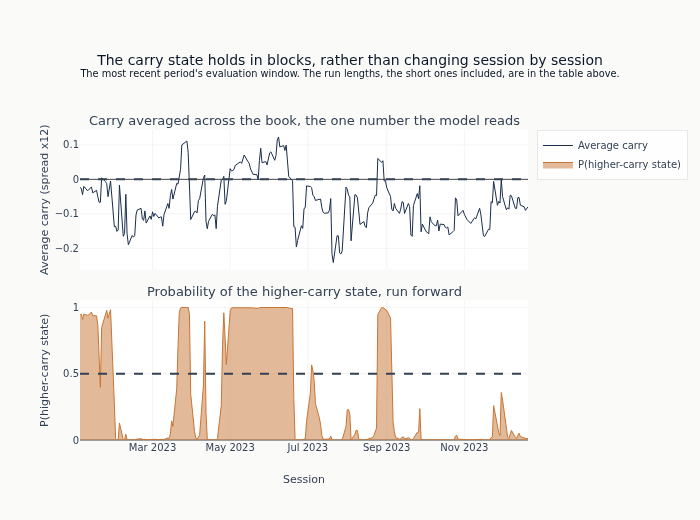

In [30]:
if len(hmm_pl) > 0:
    viz_fold = hmm_pl["fold"].min()
    viz_split = next(sp for sp in splits if sp["fold"] == viz_fold)
    hmm_viz = (
        hmm_pl.filter(pl.col("fold") == viz_fold)
        .filter(
            (pl.col("timestamp") >= _as_date(viz_split["val_start"]))
            & (pl.col("timestamp") <= _as_date(viz_split["val_end"]))
        )
        .sort("timestamp")
    )
    port_viz = portfolio_carry.join(
        hmm_viz.select(["timestamp", "hmm_carry_regime_prob"]), on="timestamp", how="inner"
    ).sort("timestamp")

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        subplot_titles=[
            "Carry averaged across the book, the one number the model reads",
            "Probability of the higher-carry state, run forward",
        ],
        vertical_spacing=0.1,
    )

    fig.add_trace(
        go.Scatter(
            x=port_viz["timestamp"].to_list(),
            y=port_viz["portfolio_carry"].to_list(),
            name="Average carry",
            line=dict(width=1, color=COLORS["slate"]),
        ),
        row=1,
        col=1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)

    fig.add_trace(
        go.Scatter(
            x=port_viz["timestamp"].to_list(),
            y=port_viz["hmm_carry_regime_prob"].to_list(),
            name="P(higher-carry state)",
            line=dict(width=1, color=COLORS["copper"]),
            fill="tozeroy",
        ),
        row=2,
        col=1,
    )
    fig.add_hline(y=0.5, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

    fig.update_annotations(font_size=13)
    fig.update_layout(
        height=520,
        margin={"t": 130},
        title_text=(
            "The carry state holds in blocks, rather than changing session by session"
            "<br><sup>The most recent period's evaluation window. The run lengths, "
            "the short ones included, are in the table above.</sup>"
        ),
    )
    fig.update_yaxes(title_text="Average carry (spread x12)", row=1, col=1)
    fig.update_yaxes(title_text="P(higher-carry state)", row=2, col=1)
    fig.update_xaxes(title_text="Session", row=2, col=1)
    show_plotly_with_alt(
        fig,
        "Two stacked panels over the most recent evaluation window, about one year of sessions. "
        "The upper panel is a line of carry averaged across the book, wandering either side of "
        "zero and spending most of the window below it. The lower panel is the filtered "
        "probability of the higher-carry state, shaded under the line, against a dashed rule at "
        "0.5. That probability does not drift across the middle: it sits pinned near 0 or near "
        "1 for stretches of weeks and switches between them quickly, so the state reads as "
        "blocks rather than as a session-by-session wobble.",
    )

## D. Do the estimates move as the window rolls?

The training windows roll forward one year at a time, so the estimated parameters
should move slowly. Two failure modes sit either side of that. Parameters identical in
every period say the re-estimation bought nothing and a single fit would have done.
Parameters that swing say the feature built on them means something different in each
period, which is a warning about the feature rather than about the model.

**Only the hidden Markov model has a per-period parameter to draw.** The Fourier
transform estimates nothing, which is why its values are identical everywhere. ARIMA
does estimate weights, but they are re-estimated every `ARIMA_REFIT_FREQ` sessions
*within* each period, so there is no single set of ARIMA weights per period to plot; the
equivalent question for it is answered by the walk itself.

The left panel is the pair of state averages, in the units of the carry series the
states are named for. The right panel is the probability each state assigns to staying
put next session - the same quantity `hmm_regime_duration` depends on - converted into
the run length it implies, $1/(1-p_{\text{stay}})$. Drawn as probabilities they all sit
against the top of the axis and the movement between periods is invisible; drawn in
sessions it is the size it actually is. The table carries both: `persist_low` and
`persist_high` are the probabilities, `run_low` and `run_high` the run lengths they
imply.

In [31]:
if hmm_fold_params:
    hmm_param_df = pl.DataFrame(hmm_fold_params).sort("fold")
    print("\nEstimated parameters per period, states ordered by average carry:")
    hmm_param_display = (
        hmm_param_df.with_columns(
            (1.0 / (1.0 - pl.col("persist_low"))).round(1).alias("run_low"),
            (1.0 / (1.0 - pl.col("persist_high"))).round(1).alias("run_high"),
        )
        .with_columns(
            pl.col("mean_carry_low", "mean_carry_high").round(4),
            pl.col("persist_low", "persist_high").round(4),
        )
        .rename({"fold": "period", "train_last": "last_session_estimated_on"})
        .select(
            "period",
            "mean_carry_low",
            "mean_carry_high",
            "persist_low",
            "persist_high",
            "run_low",
            "run_high",
            "n_train",
            "last_session_estimated_on",
        )
    )
else:
    hmm_param_df = pl.DataFrame(
        schema={
            "fold": pl.Int64,
            "mean_carry_low": pl.Float64,
            "mean_carry_high": pl.Float64,
            "persist_low": pl.Float64,
            "persist_high": pl.Float64,
            "n_train": pl.Int64,
            "train_last": pl.Date,
        }
    )
    hmm_param_display = hmm_param_df
    print("No period was estimated; the parameter panel below is omitted")


Estimated parameters per period, states ordered by average carry:


In [32]:
hmm_param_display

period,mean_carry_low,mean_carry_high,persist_low,persist_high,run_low,run_high,n_train,last_session_estimated_on
i64,f64,f64,f64,f64,f64,f64,i64,date
0,-0.0956,0.0107,0.9553,0.9599,22.4,24.9,2059,2022-12-22
1,-0.0949,0.0147,0.9541,0.9586,21.8,24.1,2059,2021-12-23
2,-0.101,0.0098,0.955,0.9634,22.2,27.3,2059,2020-12-24
3,-0.0856,0.023,0.9548,0.9536,22.1,21.6,2059,2019-12-24
4,-0.0796,0.0268,0.9568,0.9544,23.2,21.9,1978,2018-12-24


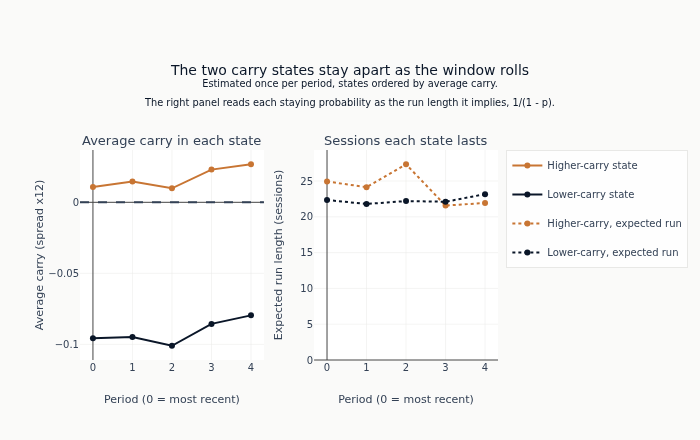

In [33]:
if len(hmm_param_df) > 0:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=["Average carry in each state", "Sessions each state lasts"],
        horizontal_spacing=0.12,
    )
    for column, name, color in (
        ("mean_carry_high", "Higher-carry state", COLORS["copper"]),
        ("mean_carry_low", "Lower-carry state", COLORS["blue"]),
    ):
        fig.add_trace(
            go.Scatter(
                x=hmm_param_df["fold"].to_list(),
                y=hmm_param_df[column].to_list(),
                mode="lines+markers",
                name=name,
                line={"color": color},
                legendgroup=name,
            ),
            row=1,
            col=1,
        )
    for column, name, color in (
        ("persist_high", "Higher-carry, expected run", COLORS["copper"]),
        ("persist_low", "Lower-carry, expected run", COLORS["blue"]),
    ):
        fig.add_trace(
            go.Scatter(
                x=hmm_param_df["fold"].to_list(),
                y=(1.0 / (1.0 - hmm_param_df[column])).to_list(),
                mode="lines+markers",
                name=name,
                line={"color": color, "dash": "dot"},
                legendgroup=name,
            ),
            row=1,
            col=2,
        )
    fig.add_hline(y=0.0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)
    fig.update_annotations(font_size=13)
    fig.update_yaxes(title_text="Average carry (spread x12)", row=1, col=1)
    fig.update_yaxes(title_text="Expected run length (sessions)", rangemode="tozero", row=1, col=2)
    fig.update_xaxes(title_text="Period (0 = most recent)", row=1, col=1)
    fig.update_xaxes(title_text="Period (0 = most recent)", row=1, col=2)
    fig.update_layout(
        title=(
            "The two carry states stay apart as the window rolls"
            "<br><sup>Estimated once per period, states ordered by average carry."
            "<br>The right panel reads each staying probability as the run length it "
            "implies, 1/(1 - p).</sup>"
        ),
        height=440,
        margin={"t": 150},
    )
    show_plotly_with_alt(
        fig,
        "Two side-by-side line panels with one point per period, period 0 most recent, five "
        "periods in all. The left panel plots average carry in each state: the higher-carry "
        "state stays above zero and the lower-carry state well below it in every period, and "
        "the two lines never approach each other. The right panel plots one dotted line per "
        "state, each the run length that state's own staying probability implies as 1/(1 - p). "
        "Both sit a little above twenty sessions in every period and stay close together, so "
        "the states differ in the carry they carry rather than in how long they last.",
    )

**What the re-estimation bought.** Across the five periods the estimated average carry
of the lower-carry state moves between -0.1008 and -0.0795, and that of the higher-carry
state between 0.0101 and 0.0269, so the two never come close to each other as the window
rolls and the feature keeps meaning the same thing throughout. The probability of
staying put next session stays between 0.9536 and 0.9632, which the table reads as
expected runs of 21.6 to 27.2 sessions. Parameters that move this little across eight
years of rolling windows say the re-estimation is cheap insurance rather than a source
of variation in the feature - but that is a fact about this signal on this universe, not
a reason to skip the re-estimation on another one.

---

## E. Combining the three and writing the file

The three models produce values at three different levels of detail. ARIMA gives one
value per product, session and period. The spectral features give one per product and
session, copied across periods. The regime features give one per session, shared by
every product because the model reads the book as a whole.

They are brought onto one grid: every combination of session, product and contract
position that the price file contains, repeated once per period. A left join then
attaches each family where it has a value and leaves an empty cell where it does not,
so nothing is invented and no row is dropped for lack of a feature.

In [34]:
base_grid = df.select(["timestamp", "product", "position"]).unique()
base = pl.concat([base_grid.with_columns(pl.lit(s["fold"]).alias("fold")) for s in splits])

if len(arima_pl) > 0:
    base = base.join(arima_pl, on=["product", "timestamp", "fold"], how="left")
    print(
        f"ARIMA features joined: {[c for c in arima_pl.columns if c not in ('product', 'timestamp', 'fold')]}"
    )
else:
    base = base.with_columns(
        pl.lit(None).cast(pl.Float64).alias("arima_carry_forecast"),
        pl.lit(None).cast(pl.Float64).alias("arima_carry_residual"),
    )

ARIMA features joined: ['arima_carry_forecast', 'arima_carry_residual']


In [35]:
if len(fft_pl) > 0:
    base = base.join(fft_pl, on=["product", "timestamp", "fold"], how="left")
    print(
        f"FFT features joined: {[c for c in fft_pl.columns if c not in ('product', 'timestamp', 'fold')]}"
    )
else:
    for col in [
        "fft_spectral_energy",
        "fft_dominant_period",
        "fft_spectral_entropy",
        "fft_energy_63d",
        "fft_energy_126d",
    ]:
        base = base.with_columns(pl.lit(None).cast(pl.Float64).alias(col))

FFT features joined: ['fft_spectral_energy', 'fft_dominant_period', 'fft_spectral_entropy', 'fft_energy_63d', 'fft_energy_126d']


In [36]:
# One regime value per session, so it repeats across the products of that session.
if len(hmm_pl) > 0:
    base = base.join(hmm_pl, on=["timestamp", "fold"], how="left")
    print(f"HMM features joined: {[c for c in hmm_pl.columns if c not in ('timestamp', 'fold')]}")
else:
    base = base.with_columns(
        pl.lit(None).cast(pl.Float64).alias("hmm_carry_regime_prob"),
        pl.lit(None).cast(pl.Float64).alias("hmm_regime_duration"),
    )

temporal_features = base.sort(["fold", "product", "position", "timestamp"])

HMM features joined: ['hmm_carry_regime_prob', 'hmm_regime_duration']


In [37]:
temporal_cols = [
    c for c in temporal_features.columns if c not in ("timestamp", "product", "position", "fold")
]
print(
    f"\n{len(temporal_features):,} rows, {len(temporal_cols)} features, "
    f"{temporal_features['fold'].n_unique()} periods"
)
print(f"Features: {temporal_cols}")


1,563,890 rows, 9 features, 5 periods
Features: ['arima_carry_forecast', 'arima_carry_residual', 'fft_spectral_energy', 'fft_dominant_period', 'fft_spectral_entropy', 'fft_energy_63d', 'fft_energy_126d', 'hmm_carry_regime_prob', 'hmm_regime_duration']


How much of the grid each feature actually fills. The share is taken over the whole
grid, which includes every session of every period and is far larger than any one
model's window, so these are not quality scores - they are a check that each family
landed where it was supposed to and nowhere else.

ARIMA's share is the lowest of the three, for two reasons that are both by
construction: the burn-in head of each period, which no forecast can cover, and the
shared walk length taken from the shortest series. Both losses fall at the front of a
period's window, which is training. **This table understates what the models
downstream receive**, because most of the grid it counts over is outside any walk. The
count printed under section C.1 is the one to read for that: it is taken against the
product-sessions each evaluation window quotes, and it is complete or nearly so.

The spectral features fill nearly everything, since they run over the full history and
are copied to every period. The regime features fill each period's training and
evaluation span, one value per session repeated across that session's products.

In [38]:
print("\nShare of the grid each feature fills:")
for col in temporal_cols:
    non_null = temporal_features.select(pl.col(col).is_not_null().sum()).item()
    pct = non_null / len(temporal_features) * 100
    print(f"  {col}: {pct:.1f}%")


Share of the grid each feature fills:
  arima_carry_forecast: 20.4%
  arima_carry_residual: 20.4%
  fft_spectral_energy: 97.1%
  fft_dominant_period: 97.1%
  fft_spectral_entropy: 97.1%
  fft_energy_63d: 97.1%
  fft_energy_126d: 97.1%
  hmm_carry_regime_prob: 59.0%
  hmm_regime_duration: 59.0%


### What is written, and what the checks before the write are for

`features/financial.parquet` and `features/model_based.parquet` are two separate files
and neither reads the other. The model notebooks in Chapter 11 onward read both and
join them on `(fold, timestamp, product, position)`. The period number is part of that
key on purpose: it is what makes a model training on one period receive the features
estimated on that period's training sessions, rather than a single set estimated once.

Three properties are asserted before the file is written. The key is unique, so no join
downstream can silently multiply rows. No period's rows escape its own window. And the
columns carrying a value on a holdout-dated row are exactly the ones allowed to.

That last check is the one worth reading closely, because the answer is not "none".
ARIMA and the hidden Markov model estimate parameters and are confined to their period,
so every holdout-dated cell they own has to be empty, and the assertion enforces it.
The spectral features estimate nothing and read a backward-looking window, so their
holdout-dated cells are filled on purpose - a later stage evaluating on the holdout
needs them, and there is nothing about them that could have come from the future. The
cell prints the count per column, which is where that distinction becomes visible.

In [39]:
key = ["fold", "timestamp", "product", "position"]
duplicate_keys = temporal_features.select(pl.struct(key).is_duplicated().sum()).item()
assert duplicate_keys == 0, f"{duplicate_keys} duplicate rows on {key}"

FITTED_COLUMNS = [
    "arima_carry_forecast",
    "arima_carry_residual",
    "hmm_carry_regime_prob",
    "hmm_regime_duration",
]
FFT_COLUMNS = [c for c in temporal_cols if c.startswith("fft_")]
assert sorted(FITTED_COLUMNS + FFT_COLUMNS) == sorted(temporal_cols), (
    "a feature column belongs to neither the estimated nor the spectral family; "
    "classify it before the check below can mean anything"
)

held_out = temporal_features.filter(pl.col("timestamp") >= HOLDOUT_START)
holdout_counts = pl.DataFrame(
    {
        "feature": temporal_cols,
        "family": ["estimated" if c in FITTED_COLUMNS else "spectral" for c in temporal_cols],
        "values_on_holdout_dates": [
            held_out.select(pl.col(c).is_not_null().sum()).item() for c in temporal_cols
        ],
    }
)
for col, n_held in zip(
    holdout_counts["feature"], holdout_counts["values_on_holdout_dates"], strict=True
):
    if col in FITTED_COLUMNS:
        assert n_held == 0, f"{col} comes from an estimate and has {n_held} holdout-dated values"

print(f"The key {key} is unique across all {len(temporal_features):,} rows")
print(f"Rows dated on or after the holdout opens: {len(held_out):,} of {len(temporal_features):,}")
holdout_counts

The key ['fold', 'timestamp', 'product', 'position'] is unique across all 1,563,890 rows
Rows dated on or after the holdout opens: 217,605 of 1,563,890


feature,family,values_on_holdout_dates
str,str,i64
"""arima_carry_forecast""","""estimated""",0
"""arima_carry_residual""","""estimated""",0
"""fft_spectral_energy""","""spectral""",216330
"""fft_dominant_period""","""spectral""",216330
"""fft_spectral_entropy""","""spectral""",216330
"""fft_energy_63d""","""spectral""",216330
"""fft_energy_126d""","""spectral""",216330
"""hmm_carry_regime_prob""","""estimated""",0
"""hmm_regime_duration""","""estimated""",0


### The file, and the fingerprint written beside it

The file is written with a small companion file recording four things: a **content
fingerprint** of the feature values, the number of rows, the columns that form the key,
and the fingerprint of the prices these features were built from.

The fingerprint is what makes the record useful rather than decorative. A registry that
notes only which feature *names* a model was trained on cannot tell two training runs
apart when the names are identical and the values are not - which is exactly the
situation after a bug in this notebook is fixed. Two runs whose values differ get
different fingerprints even when the row count and the column names match, so a
training run downstream can record which version of the features it read.

The upstream fingerprint is taken over the raw settlement prices, because section C
recomputes carry from them. This notebook reads no other case study file for a feature
value, and the record says so.

In [40]:
output_path = FEATURES_DIR / "model_based.parquet"
record = write_artifact(
    temporal_features,
    output_path,
    keys=key,
    written_by=f"case_studies/{STRATEGY_ID}/04_model_based_features.py",
    inputs={
        "load_cme_futures": value_digest(
            df.select(["product", "position", "timestamp", "raw_close"])
        )
    },
)
print(
    f"Written to case_studies/{STRATEGY_ID}/features/model_based.parquet, "
    f"fingerprint {record['digest']}"
)

Written to case_studies/cme_futures/features/model_based.parquet, fingerprint ba55572a8d67d027


## F. Do these features rank products the returns agree with?

One question, asked on evaluation sessions: does each feature line the products up in
an order that the forward returns bear out? The measure is the **information
coefficient** - on each session, rank the products by the feature, rank them by the
return that followed, and take the correlation between the two rankings. That gives one
number per session, and averaging those numbers over the evaluation sessions gives the
feature's IC.

**This screen selects nothing.** Every feature above is already in the file, whatever
comes out here. [`05_evaluation`](05_evaluation.ipynb) is where feature evidence is
weighed against everything else the case study knows.

Two scoping rules are what make the number mean what its name says.

**Evaluation sessions only.** Each period contributes rows dated inside its own
evaluation window and nothing from its training window. A feature scored on sessions
the model was estimated on would be scored on its own answers.

**The boundary is where the outcome settles, not where the decision is made.** This is
the one place in the notebook where a forward return is read, so it is the one place
the holdout binds on the outcome rather than on the estimate. A decision on date `t`
carrying a return over `LABEL_HORIZON_SESSIONS` sessions is settled that many sessions
after `t`, so the last date that can be scored is `LAST_SCORABLE_DECISION_DATE`, printed
in section B.

In [41]:
temporal_ic = {}
ic_table = pl.DataFrame()

The rows the screen is allowed to see, and nothing else. The count printed under it
says how many rows the outcome boundary removed on top of what the period windows
already excluded, so the reader can see whether that boundary binds here or not.

In [42]:
def _build_temporal_eval_frame(features_df: pl.DataFrame):
    label_path = CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet"
    if not label_path.exists():
        return None, None
    label_df = pl.read_parquet(label_path)
    label_col = [c for c in label_df.columns if c not in ("timestamp", "product", "position")][0]

    # Evaluation rows only, taken per period from that period's own evaluation window.
    validation = pl.concat(
        [
            features_df.filter(
                (pl.col("fold") == split["fold"])
                & (pl.col("timestamp") >= _as_date(split["val_start"]))
                & (pl.col("timestamp") <= _as_date(split["val_end"]))
            )
            for split in splits
        ]
    )

    labelled = (
        validation.filter(pl.col("position") == 0)
        .join(
            label_df.filter(pl.col("position") == 0).select(["timestamp", "product", label_col]),
            on=["timestamp", "product"],
            how="inner",
        )
        .unique(subset=["timestamp", "product"], keep="first")
    )
    eval_df = labelled.filter(pl.col("timestamp") <= LAST_SCORABLE_DECISION_DATE).sort(
        ["timestamp", "product"]
    )
    print(
        f"The outcome boundary removes {len(labelled) - len(eval_df):,} of "
        f"{len(labelled):,} labelled evaluation rows."
    )
    return eval_df, label_col

The per-session series comes from `cross_sectional_ic_series`, which returns its rows in
date order. That is the property the next call depends on, and it is worth stating why.

Consecutive daily decisions overlap: a return measured over `LABEL_HORIZON_SESSIONS`
sessions starting today and one starting tomorrow share all but one of those sessions,
so the daily series is correlated with itself and the usual standard error, which
assumes independent observations, is too small. The correction for that is Newey-West,
which widens the standard error using the series' own correlation with itself out to
some number of lags.

**How many lags is not simply the overlap.** The overlap sets a floor - a return over
`LABEL_HORIZON_SESSIONS` sessions guarantees dependence out to one session short of it
- but the series can be correlated for longer than that for reasons the horizon does
not know about, so the standard rule of thumb, which grows with the number of sessions,
is used where it asks for more. The lag in force is the larger of the two, and it is
reported per feature in the table below rather than left to be inferred from the
horizon.

The other catch is that Newey-West treats the order of the rows as the order of time and
does not sort. A series assembled by grouping comes back in whatever order the grouping
produced, which is not chronological and is not even stable between runs - so the
correction would be computed over a shuffled timeline and would return a standard error
for a dependence the data does not have. Taking the series from a function that sorts is
what avoids that.

In [43]:
def _compute_temporal_ic_stats(eval_df, feature_cols, label_col):
    from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

    output = {}
    labels = eval_df.select(["timestamp", "product", label_col])
    for feat in feature_cols:
        ic_series = cross_sectional_ic_series(
            eval_df.select(["timestamp", "product", feat]),
            labels,
            pred_col=feat,
            ret_col=label_col,
            date_col="timestamp",
            entity_col="product",
            method="spearman",
            min_obs=10,
        )
        ic_vals = ic_series["ic"].drop_nulls().drop_nans().to_numpy()
        if len(ic_vals) >= 20:
            # The horizon sets the floor on the lag; the call widens it where its own
            # rule asks for more, and reports what it settled on as `effective_lags`.
            output[feat] = compute_ic_hac_stats(ic_vals, label_horizon=LABEL_HORIZON_SESSIONS)
            # A feature whose panel is thin on some sessions loses them to `min_obs`, so
            # the count of sessions behind the average belongs beside the t-statistic.
            output[feat]["n_dates"] = len(ic_vals)
    return output

The features the screen can measure are all screened against the same return over the
same evaluation windows, so testing each one at the usual threshold and reporting
whichever passes gives as many chances at a false positive as there are features tested. **Benjamini-Hochberg** corrects for that: it raises the
bar each feature has to clear according to how many were tested, so that `FDR_ALPHA` is
the share of false positives among the features *declared* significant rather than the
share among all the tests run.

In [44]:
def _apply_fdr_significance(ic_stats: dict[str, dict]) -> list[bool]:
    from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr

    features = list(ic_stats.keys())
    p_values = [ic_stats[f]["p_value"] for f in features]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)
    rejected = fdr_result["rejected"].tolist()
    for idx, feat in enumerate(features):
        ic_stats[feat]["fdr_significant"] = rejected[idx]
    return rejected

In [45]:
if len(temporal_features) > 0:
    eval_df, label_col = _build_temporal_eval_frame(temporal_features)
    if eval_df is None:
        print("Label file not found, skipping the screen")
    else:
        print(
            f"Screening on {len(eval_df):,} front-month rows dated before the outcome "
            f"boundary, against {label_col}"
        )
        temporal_ic = _compute_temporal_ic_stats(eval_df, temporal_cols, label_col)
        if temporal_ic:
            rejected = _apply_fdr_significance(temporal_ic)
            n_fdr_sig = sum(rejected)
            n_naive_sig = sum(1 for f in temporal_ic if abs(temporal_ic[f]["t_stat"]) > 1.96)
            ic_table = pl.DataFrame(
                [
                    {
                        "feature": feat,
                        "mean_ic": stats["mean_ic"],
                        "hac_se": stats["hac_se"],
                        "hac_t": stats["t_stat"],
                        "hac_lags": stats["effective_lags"],
                        "decision_dates": stats["n_dates"],
                        "fdr_significant": stats["fdr_significant"],
                    }
                    for feat, stats in temporal_ic.items()
                ]
            ).sort("mean_ic", descending=True)
            print(
                f"\nFeatures the screen could measure: {len(temporal_ic)} of {len(temporal_cols)}"
            )
            print(f"Clearing |t| > 1.96 taken one at a time: {n_naive_sig}")
            print(
                f"Clearing Benjamini-Hochberg across all of them at alpha={FDR_ALPHA}: {n_fdr_sig}"
            )
else:
    print("No features to screen")

The outcome boundary removes 0 of 38,262 labelled evaluation rows.
Screening on 38,262 front-month rows dated before the outcome boundary, against fwd_ret_5d



Features the screen could measure: 7 of 9
Clearing |t| > 1.96 taken one at a time: 1
Clearing Benjamini-Hochberg across all of them at alpha=0.05: 0


Each row is one feature's average IC over the evaluation sessions, the standard error
and t-statistic after the Newey-West correction, how many lags that correction used,
how many sessions the average rests on, and whether it clears the multiplicity-corrected
threshold. Read `hac_lags` against `LABEL_HORIZON_SESSIONS`: where it is larger, the
rule of thumb asked for a wider window than the overlap alone requires. The chart below
draws the first column with the second as an interval.

In [46]:
ic_table

feature,mean_ic,hac_se,hac_t,hac_lags,decision_dates,fdr_significant
str,f64,f64,f64,i64,i64,bool
"""fft_dominant_period""",0.016021,0.010964,1.461205,7,1285,false
"""fft_spectral_entropy""",0.014604,0.012245,1.192622,7,1285,false
"""fft_spectral_energy""",0.003212,0.015644,0.205303,7,1285,false
"""fft_energy_126d""",-0.003593,0.012817,-0.280328,7,1285,false
"""arima_carry_residual""",-0.011288,0.006783,-1.664206,7,1283,false
"""arima_carry_forecast""",-0.014181,0.01064,-1.332797,7,1283,false
"""fft_energy_63d""",-0.031406,0.014889,-2.109305,7,1285,false


### What the screen found

Average IC per feature, sorted, with the bars that clear the corrected threshold filled
and the rest drawn hollow. Read the filled-or-hollow distinction rather than the
t-statistic beside it: all of these features were screened against the same return over
the same evaluation windows, so a large t-statistic on any one of them is not on its own
evidence about that one.

The two regime features are absent from the chart. They take the same value for every
product on a given session, so ranking products by them produces no ranking at all and
the correlation is undefined. That is a property of the measure and says nothing about
the features: a regime variable works by conditioning other signals rather than by
ranking on its own, and testing it needs an interaction term or a comparison between
models fitted with and without it. This notebook runs neither, and neither does the
one-feature-at-a-time screen in [`05_evaluation`](05_evaluation.ipynb).

**This selects nothing.** Every feature above is already in `model_based.parquet`,
written in section E, whatever the bars say.

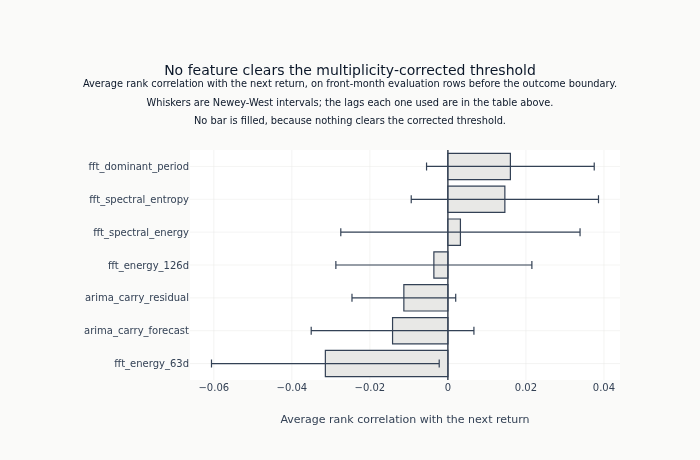

In [47]:
if temporal_ic:
    ic_rows = sorted(temporal_ic.items(), key=lambda item: item[1]["mean_ic"])
    names = [name for name, _ in ic_rows]
    values = [stats["mean_ic"] for _, stats in ic_rows]
    errors = [1.96 * stats["hac_se"] for _, stats in ic_rows]
    retained = [bool(stats["fdr_significant"]) for _, stats in ic_rows]
    # Filled where retained, hollow where not: the palette's dark end is four navies
    # that do not separate as bars, so the distinction is carried by lightness.
    fill = [
        (COLORS["blue"] if value >= 0 else COLORS["copper"]) if keep else COLORS["silver_muted"]
        for value, keep in zip(values, retained, strict=True)
    ]
    edge = [
        (COLORS["blue"] if value >= 0 else COLORS["copper"]) if keep else COLORS["neutral"]
        for value, keep in zip(values, retained, strict=True)
    ]
    fig = go.Figure(
        go.Bar(
            x=values,
            y=names,
            orientation="h",
            marker={"color": fill, "line": {"color": edge, "width": 1.2}},
            error_x={
                "type": "data",
                "array": errors,
                "color": COLORS["neutral"],
                "thickness": 1.2,
                "width": 4,
            },
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
    fig.update_layout(
        title=(
            "No feature clears the multiplicity-corrected threshold"
            if n_fdr_sig == 0
            else "How the features rank products on evaluation sessions"
        )
        + (
            "<br><sup>Average rank correlation with the next return, on front-month "
            "evaluation rows before the outcome boundary.<br>Whiskers are Newey-West "
            "intervals; the lags each one used are in the table above.<br>"
            + (
                "No bar is filled, because nothing clears the corrected threshold.</sup>"
                if n_fdr_sig == 0
                else "Filled bars clear the corrected threshold; hollow bars do not.</sup>"
            )
        ),
        xaxis_title="Average rank correlation with the next return",
        yaxis_title="",
        height=460,
        margin={"l": 190, "t": 150},
    )
    show_plotly_with_alt(
        fig,
        "Horizontal bar chart of the average rank correlation with the next return, one bar per "
        "temporal feature, sorted from the most positive at the top to the most negative at the "
        "bottom. Every bar is short, within a few hundredths of zero, and each carries a "
        "Newey-West whisker several times its own length that crosses zero. "
        + (
            "No bar is filled, because none clears the multiplicity-corrected threshold."
            if n_fdr_sig == 0
            else f"{n_fdr_sig} filled bars clear the multiplicity-corrected threshold; the "
            "hollow ones do not."
        ),
    )
else:
    print("Chart omitted: no feature produced enough sessions to measure.")

**What the screen measured.** 38,244 front-month rows across 1285 evaluation sessions
carry a return, and 7 of the 9 features admit a ranking across products at all. The
average rank correlation runs from -0.031161 for `fft_energy_63d`, whose corrected
t-statistic is -2.102071, up to 0.016074 for `fft_dominant_period` at 1.468945. One
feature clears |t| > 1.96 taken on its own, and none clears Benjamini-Hochberg across
the seven.

Two things in the table are worth reading before the bars. The correction used 7 lags
for every feature, not the 5 sessions of the label horizon, because the rule of thumb
asked for a wider window than the overlap alone requires - which is why the lag is
reported rather than assumed. And the outcome boundary removed 0 rows, because the
evaluation windows already stop short of it: it is asserted here so that it would bind
if the windows ever changed, not because it binds today.

## Key Takeaways

1. **A feature whose value comes out of an estimated model carries the estimation
   window in its information set.** That is the difference between this stage and the
   last one, and the rule it implies is that no parameter behind a session's value may
   have seen that session or a later one. The hazard does not show up as an error or as
   an implausible number; it shows up as a feature that works in research and not
   afterwards.
2. **Bounding where the parameters came from is only half of it. The model also has to
   be applied forward.** The library call that answers "which state was the market in" conditions
   on the whole series by default, and its answer for a past session changes when later
   data arrives. Ask for the forward answer, and check it by deleting later
   observations and confirming the earlier values do not move - which is what section
   C.3 does rather than asserting.
3. **There is more than one honest way to bound the parameters, and they need different
   evidence.** Estimating once per period and holding the parameters fixed is checkable
   against a date, so C.3 checks it. Refitting as the walk proceeds, each time on a
   prefix that ends before what it forecasts, is equally causal but leaves no date to
   check - it is guaranteed by how the call is constructed instead, so C.1 says so
   rather than asserting something weaker and calling it proof. Decide which of the two
   a model is doing before deciding what would count as evidence for it.
4. **Distinguish a model that estimates from one that only transforms.** ARIMA and the
   hidden Markov model estimate parameters and so are confined to a period. The Fourier
   transform estimates nothing, so it runs over the full history and its values on
   holdout-dated rows are legitimate. Section E prints the count per column, so the two
   kinds are visibly different rather than assumed alike.
5. **Correct twice before reading a t-statistic, and report what the correction did.**
   Consecutive decisions share most of their outcome window, so the uncorrected
   standard error is too small; and testing a family of features at once gives as many
   chances at a false positive as there are members. Neither correction is a single fixed number - the lag the first one
   uses is chosen from the data, so section F prints it per feature rather than letting
   the reader assume it equals the horizon.
6. **Record what the features were, not just what they were called.** The fingerprint
   written beside the file is what lets a training run downstream say which version of
   these values it read, so that fixing a bug here cannot silently produce two training
   runs that look identical in the record.

**Known limitations.** The average carry the regime model reads is taken over whichever
products settled, with a two-session hold for the rest, so it is not a fixed basket;
section C.3 measures how much of the gap that hold covers and how much it does not. The
screen in section F cannot measure the two regime features at all, because they do not
vary across products within a session, so what those features are worth is not settled
here. And the walk in C.1 uses one length for every product in a period, taken from the
shortest, so products with longer histories lose their earliest sessions.

**Writes**: `features/model_based.parquet`, keyed on
`(fold, timestamp, product, position)`, with its fingerprint recorded alongside.

**Next**: [`05_evaluation`](05_evaluation.ipynb) weighs these features against the ones
from [`03_financial_features`](03_financial_features.ipynb); the model notebooks from
Chapter 11 onward read both files together.